<a href="https://www.kaggle.com/code/kathmer/kidney-stone-ml?scriptVersionId=300855261" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"/kaggle/input/datasets/vuppalaadithyasairam/kidney-stone-prediction-based-on-urine-analysis/kindey stone urine analysis.csv")

# Initial Inspection

In [3]:
df.head()

,gravity,ph,osmo,cond,urea,calc,target
0,1.021,4.91,725,14.0,443,2.45,0
1,1.017,5.74,577,20.0,296,4.49,0
2,1.008,7.20,321,14.9,101,2.36,0
3,1.011,5.51,408,12.6,224,2.15,0
4,1.005,6.52,187,7.5,91,1.16,0


In [4]:
df.shape

(79, 7)

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
gravity,79.0,1.02,0.01,1.00,1.01,1.02,1.02,1.04
ph,79.0,6.03,0.72,4.76,5.53,5.94,6.38,7.94
osmo,79.0,612.85,237.51,187.00,413.00,594.00,792.00,1236.00
cond,79.0,20.81,7.94,5.10,14.15,21.40,26.55,38.00
urea,79.0,266.41,131.25,10.00,160.00,260.00,372.00,620.00
calc,79.0,4.14,3.26,0.17,1.46,3.16,5.93,14.34
target,79.0,0.43,0.50,0.00,0.00,0.00,1.00,1.00


In [6]:
df[df.duplicated()]

,gravity,ph,osmo,cond,urea,calc,target


In [7]:
df[df.isna().any(axis=1)]

,gravity,ph,osmo,cond,urea,calc,target


In [8]:
df[df.isnull().any(axis=1)]

,gravity,ph,osmo,cond,urea,calc,target


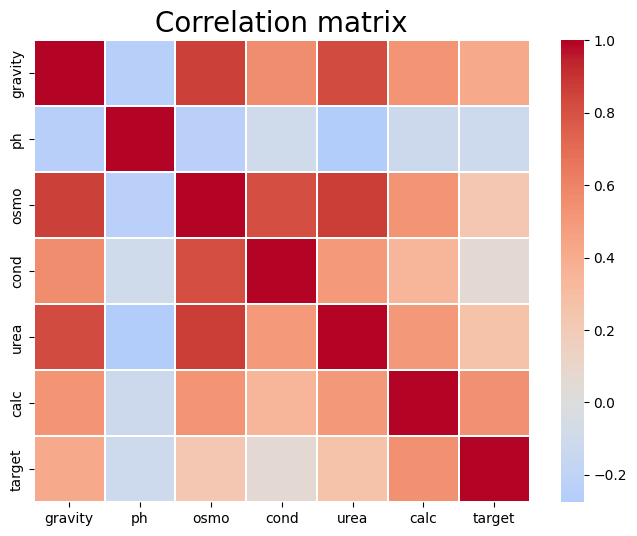

In [9]:
corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation matrix", fontsize=20)
plt.show()

# Target

target = 1 → kidney stone present

target = 0 → no kidney stone

# Random forest

STAGE 1 — Load & Inspect Data

In [10]:
df["target"].value_counts()

target
0    45
1    34
Name: count, dtype: int64

The dataset looks balanced and ready for modeling

STAGE 2 — Define X and y

In [11]:
X = df.drop(columns='target')
y = df['target']

STAGE 3 — Train/Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

STAGE 4 — Train Model

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

STAGE 5 — Make Predictions

In [14]:
pred = model.predict(X_test)

STAGE 6 — Evaluate Model 

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_score(y_test, pred)

0.6875

69% of model accuracy

In [16]:
confusion_matrix(y_test, pred)

array([[6, 3],
       [2, 5]])

How did my model’s predictions compare to reality?

0 no stone: 6 true negatives, 3 false positives
1 kidney stone: 2 false negatives, 5 true positive

The model correctly identifies most patients, detecting 5 out of 7 kidney stones while producing 3 false alarms and missing 2 cases

STAGE 7 — Global Interpretation

<Axes: >

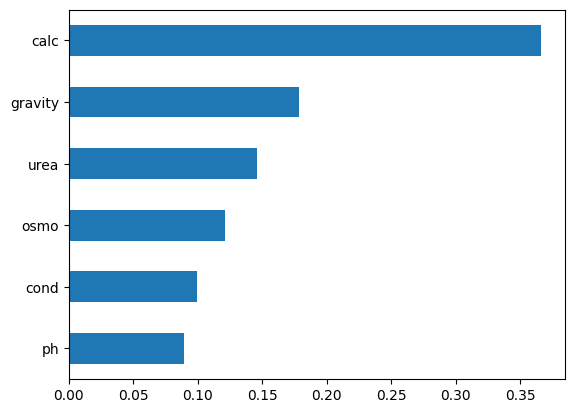

In [17]:
pd.Series(model.feature_importances_, index=X.columns).sort_values().plot.barh()

Kidney stones are mostly predicted by calcium level and how concentrated the urine is.

This makes real-world sense because most stones are calcium-based. 

<Axes: >

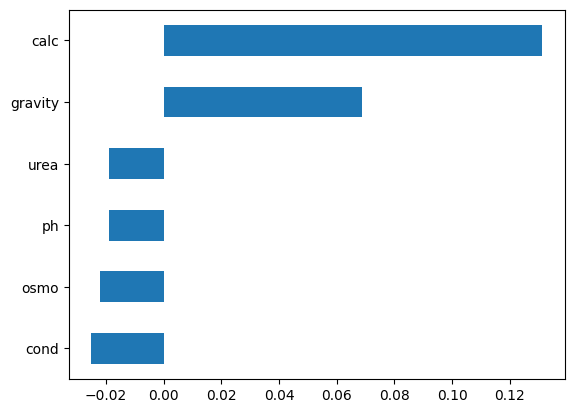

In [18]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=42)

pd.Series(result.importances_mean,index=X.columns).sort_values().plot.barh()


The model mostly depends on calcium + urine concentration, like stated before. 
THe drop after gravity suggest the dataset may contain redundant measurements. 

Stage 8 Find errors

In [19]:
wrong_mask = y_test != pred

X_wrong = X_test[wrong_mask]
y_wrong = y_test[wrong_mask]

X_wrong

,gravity,ph,osmo,cond,urea,calc
7,1.029,5.67,1107,35.9,550,8.48
70,1.028,4.76,312,12.4,10,0.27
53,1.011,7.01,443,21.4,124,1.27
20,1.024,6.30,874,29.9,380,5.16
18,1.008,6.88,395,26.1,95,7.68


In [20]:
X_correct = X_test[~wrong_mask]

In [21]:
print(" Wrong predictions:")
print(X_wrong.mean())

print("\n Correct predictions:")
print(X_correct.mean())

 Wrong predictions:
gravity      1.020
ph           6.124
osmo       626.200
cond        25.140
urea       231.800
calc         4.572
dtype: float64

 Correct predictions:
gravity      1.019273
ph           5.925455
osmo       654.454545
cond        21.509091
urea       281.909091
calc         4.501818
dtype: float64


# Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [26]:
pred = model.predict(X_test_scaled)

In [27]:
accuracy_score(y_test, pred)

0.75

75% accuracy score

In [28]:
confusion_matrix(y_test, pred)

array([[6, 3],
       [1, 6]])

In [29]:
pd.Series(model.coef_[0], index=X.columns).sort_values()

cond      -0.583563
urea      -0.416112
osmo      -0.373951
ph        -0.081206
gravity    1.320645
calc       1.669792
dtype: float64

Out of 16 patients:

- 12 correct predictions

- -4 mistakes

- only 1 missed stone

The model says kidney stones are mainly predicted by calcium and urine concentration, while other measurements fine-tune the decision.

In [30]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.86      0.67      0.75         9
           1       0.67      0.86      0.75         7

    accuracy                           0.75        16
   macro avg       0.76      0.76      0.75        16
weighted avg       0.77      0.75      0.75        16



Logistic regression achieved 75% accuracy, detecting most kidney stone cases while maintaining balanced overall performance

KEY INSIGHTS

- Calcium (calc) and urine concentration (gravity) are the strongest predictors of kidney stones in this dataset.

- The model detects most kidney stone cases (high recall = 0.86), meaning it rarely misses affected patients.

- Some false positives occur, so healthy patients may occasionally be flagged as at risk.

- Logistic Regression performed better and more interpretable than Random Forest for this dataset.

- Overall performance (75% accuracy) suggests urine chemistry contains meaningful but not perfect predictive information.